In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

# Set paths for training and testing folders for JAFFE
train_folder_path_jaffe = "/content/drive/MyDrive/JAFFE-[70,30]/JAFFE-[70,30]/train"
test_folder_path_jaffe  = "/content/drive/MyDrive/JAFFE-[70,30]/JAFFE-[70,30]/test"
# Set paths for training and testing folders for CK+
train_folder_path_ck = "/content/drive/My Drive/CK_Update/CK/CK+/train"
test_folder_path_ck = "/content/drive/My Drive/CK_Update/CK/CK+/test"

In [ ]:

# CELL 4: CHECK FOLDERS
def inspect_folder(folder_path):
    print(f"\nChecking: {folder_path}")
    print("Exists:", os.path.exists(folder_path))
    if os.path.exists(folder_path):
        classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print("Classes:", classes)
        for cls in classes:
            cls_path = os.path.join(folder_path, cls)
            count = len(os.listdir(cls_path))
            print(f"{cls}: {count} files")

inspect_folder(train_folder_path_jaffe)
inspect_folder(test_folder_path_jaffe)
inspect_folder(train_folder_path_ck)
inspect_folder(test_folder_path_ck)


Checking: /content/drive/MyDrive/JAFFE-[70,30]/JAFFE-[70,30]/train
Exists: True
Classes: ['Sad', 'Surprise', 'Neutral', 'Happy', 'Angry', 'Fear']
Sad: 22 files
Surprise: 21 files
Neutral: 21 files
Happy: 22 files
Angry: 20 files
Fear: 22 files

Checking: /content/drive/MyDrive/JAFFE-[70,30]/JAFFE-[70,30]/test
Exists: True
Classes: ['Surprise', 'Sad', 'Fear', 'Angry', 'Neutral', 'Happy']
Surprise: 9 files
Sad: 9 files
Fear: 10 files
Angry: 9 files
Neutral: 9 files
Happy: 9 files

Checking: /content/drive/My Drive/CK_Update/CK/CK+/train
Exists: True
Classes: ['surprise', 'neutral', 'sadness', 'happy', 'fear', 'anger']
surprise: 58 files
neutral: 53 files
sadness: 20 files
happy: 48 files
fear: 18 files
anger: 31 files

Checking: /content/drive/My Drive/CK_Update/CK/CK+/test
Exists: True
Classes: ['neutral', 'sadness', 'surprise', 'fear', 'happy', 'anger']
neutral: 23 files
sadness: 8 files
surprise: 24 files
fear: 7 files
happy: 21 files
anger: 14 files


In [ ]:
# CELL 5: OPTIONAL FACE DETECTION
# if no face is found, original image is used

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_and_crop_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        face = img[y:y+h, x:x+w]
        return face
    return img

In [ ]:
# CELL 6: LOAD IMAGES

def load_images_from_folders(folder_path, img_size=(224, 224), use_face_detection=False):
    images = []
    labels = []

    class_names = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])

    for class_name in class_names:
        class_path = os.path.join(folder_path, class_name)

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            img = cv2.imread(file_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if use_face_detection:
                img = detect_and_crop_face(img)

            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(class_name)

    return np.array(images), np.array(labels), class_names

In [ ]:
X_train_jaffe, y_train_jaffe_raw, jaffe_classes = load_images_from_folders(train_folder_path_jaffe, IMG_SIZE)
X_test_jaffe, y_test_jaffe_raw, _ = load_images_from_folders(test_folder_path_jaffe, IMG_SIZE)

X_train_ck, y_train_ck_raw, ck_classes = load_images_from_folders(train_folder_path_ck, IMG_SIZE)
X_test_ck, y_test_ck_raw, _ = load_images_from_folders(test_folder_path_ck, IMG_SIZE)

print("JAFFE train:", X_train_jaffe.shape, "test:", X_test_jaffe.shape)
print("CK+ train:", X_train_ck.shape, "test:", X_test_ck.shape)
print("JAFFE classes:", jaffe_classes)
print("CK+ classes:", ck_classes)

JAFFE train: (128, 224, 224, 3) test: (55, 224, 224, 3)
CK+ train: (228, 224, 224, 3) test: (97, 224, 224, 3)
JAFFE classes: ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
CK+ classes: ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']


In [ ]:
# Encode Labels
le_jaffe = LabelEncoder()
y_train_jaffe = le_jaffe.fit_transform(y_train_jaffe_raw)
y_test_jaffe = le_jaffe.transform(y_test_jaffe_raw)

le_ck = LabelEncoder()
y_train_ck = le_ck.fit_transform(y_train_ck_raw)
y_test_ck = le_ck.transform(y_test_ck_raw)

print("JAFFE label mapping:", dict(zip(le_jaffe.classes_, range(len(le_jaffe.classes_)))))
print("CK+ label mapping:", dict(zip(le_ck.classes_, range(len(le_ck.classes_)))))

JAFFE label mapping: {np.str_('Angry'): 0, np.str_('Fear'): 1, np.str_('Happy'): 2, np.str_('Neutral'): 3, np.str_('Sad'): 4, np.str_('Surprise'): 5}
CK+ label mapping: {np.str_('anger'): 0, np.str_('fear'): 1, np.str_('happy'): 2, np.str_('neutral'): 3, np.str_('sadness'): 4, np.str_('surprise'): 5}


In [ ]:
# Data Augmentation + TF Dataset
def make_tf_dataset(X, y, training=True, batch_size=16):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
        ds = ds.shuffle(len(X), seed=SEED)

    ds = ds.batch(batch_size)

    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    AUTOTUNE = tf.data.AUTOTUNE

    def preprocess_train(image, label):
        image = tf.cast(image, tf.float32)
        image = data_augmentation(image)
        image = preprocess_input(image)
        return image, label

    def preprocess_test(image, label):
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, label

    if training:
        ds = ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)

jaffe_train_ds = make_tf_dataset(X_train_jaffe, y_train_jaffe, training=True, batch_size=BATCH_SIZE)
jaffe_test_ds  = make_tf_dataset(X_test_jaffe, y_test_jaffe, training=False, batch_size=BATCH_SIZE)

ck_train_ds = make_tf_dataset(X_train_ck, y_train_ck, training=True, batch_size=BATCH_SIZE)
ck_test_ds  = make_tf_dataset(X_test_ck, y_test_ck, training=False, batch_size=BATCH_SIZE)

In [ ]:
# Class Weights
def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return {int(c): float(w) for c, w in zip(classes, weights)}

jaffe_class_weights = get_class_weights(y_train_jaffe)
ck_class_weights = get_class_weights(y_train_ck)

print("JAFFE class weights:", jaffe_class_weights)
print("CK+ class weights:", ck_class_weights)

JAFFE class weights: {0: 1.0666666666666667, 1: 0.9696969696969697, 2: 0.9696969696969697, 3: 1.0158730158730158, 4: 0.9696969696969697, 5: 1.0158730158730158}
CK+ class weights: {0: 1.2258064516129032, 1: 2.111111111111111, 2: 0.7916666666666666, 3: 0.7169811320754716, 4: 1.9, 5: 0.6551724137931034}


In [ ]:
# Build Model
#ResNet50 Transfer Learning

def build_resnet_model(num_classes):
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

In [ ]:
# Train Model Function
def train_model(train_ds, test_ds, num_classes, class_weights, model_name):
    model, base_model = build_resnet_model(num_classes)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
        ModelCheckpoint(f"{model_name}.keras", monitor="val_accuracy", save_best_only=True)
    ]

    history1 = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=15,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history2 = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=10,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    return model, history1, history2

In [ ]:
# Train JAFFE Model
jaffe_model, jaffe_hist1, jaffe_hist2 = train_model(
    jaffe_train_ds,
    jaffe_test_ds,
    num_classes=len(jaffe_classes),
    class_weights=jaffe_class_weights,
    model_name="jaffe_resnet50"
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.1484 - loss: 2.3218 - val_accuracy: 0.1455 - val_loss: 2.1049 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.1641 - loss: 2.1963 - val_accuracy: 0.2000 - val_loss: 1.8838 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.2812 - loss: 2.0058 - val_accuracy: 0.2364 - val_loss: 2.0141 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.2344 - loss: 2.0064 - val_accuracy: 0.2364 - val_loss: 1.8817 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.2812 - loss: 1.8927 - val_accuracy: 0.2545 - val_loss: 1.8461 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.2578 - loss: 1.9615 - val_accuracy: 0.3091 - val_loss: 1.8232 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.3281 - loss: 1.7806 - val_accuracy: 0.2364 - val_l

In [ ]:
# CELL 14: TRAIN CK+ MODEL
ck_model, ck_hist1, ck_hist2 = train_model(
    ck_train_ds,
    ck_test_ds,
    num_classes=len(ck_classes),
    class_weights=ck_class_weights,
    model_name="ck_resnet50"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.1842 - loss: 2.5296 - val_accuracy: 0.1031 - val_loss: 2.6972 - learning_rate: 0.0010
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.2675 - loss: 2.1068 - val_accuracy: 0.2577 - val_loss: 1.8089 - learning_rate: 0.0010
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step - accuracy: 0.3070 - loss: 2.0226 - val_accuracy: 0.3196 - val_loss: 1.7216 - learning_rate: 0.0010
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step - accuracy: 0.3596 - loss: 1.9496 - val_accuracy: 0.2990 - val_loss: 1.6667 - learning_rate: 0.0010
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.3333 - loss: 1.7428 - val_accuracy: 0.2784 - val_loss: 1.7034 - learning_rate: 0.0010
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.3246 - loss: 1.7860 - val_accuracy: 0.4330 - val_loss: 1.4334 - learning_rate: 0.0010
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step

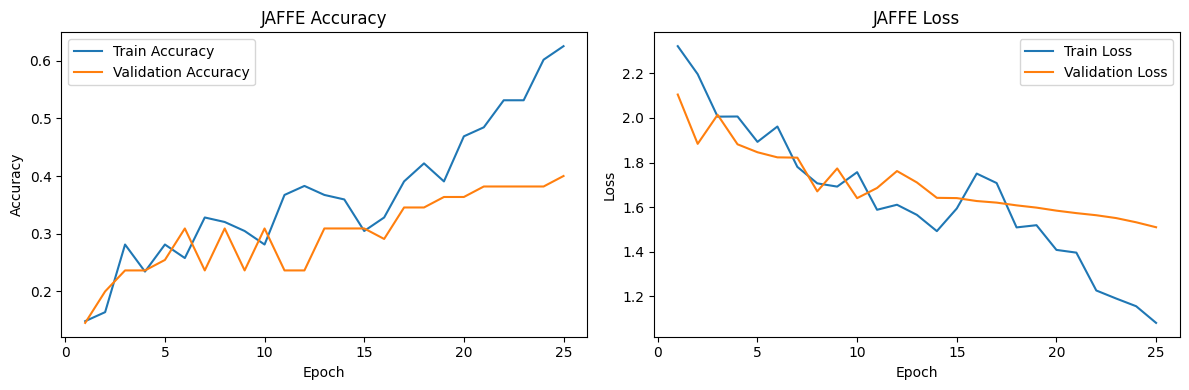

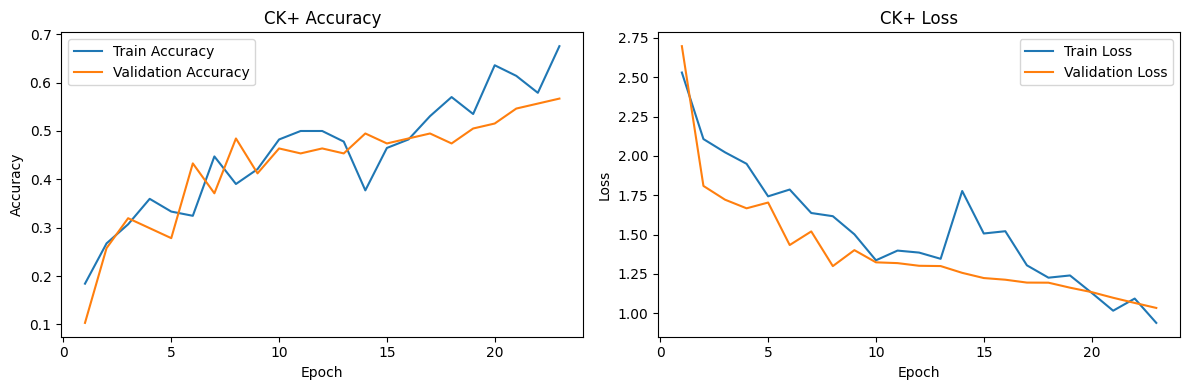

In [ ]:
# CELL 15: PLOT ACCURACY + LOSS

def plot_history(hist1, hist2, title):
    acc = hist1.history["accuracy"] + hist2.history["accuracy"]
    val_acc = hist1.history["val_accuracy"] + hist2.history["val_accuracy"]
    loss = hist1.history["loss"] + hist2.history["loss"]
    val_loss = hist1.history["val_loss"] + hist2.history["val_loss"]

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(jaffe_hist1, jaffe_hist2, "JAFFE")
plot_history(ck_hist1, ck_hist2, "CK+")

In [ ]:
# CELL 16: EVALUATION FUNCTION
def evaluate_model(model, dataset, class_names, title):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n{title}")
    print("Accuracy :", round(acc * 100, 2), "%")
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1


JAFFE Results
Accuracy : 40.0 %
Precision: 0.5688
Recall   : 0.3944
F1-score : 0.4049

Classification Report
              precision    recall  f1-score   support

       Angry       0.57      0.44      0.50         9
        Fear       0.24      0.70      0.36        10
       Happy       1.00      0.22      0.36         9
     Neutral       0.50      0.44      0.47         9
         Sad       0.50      0.22      0.31         9
    Surprise       0.60      0.33      0.43         9

    accuracy                           0.40        55
   macro avg       0.57      0.39      0.40        55
weighted avg       0.56      0.40      0.40        55



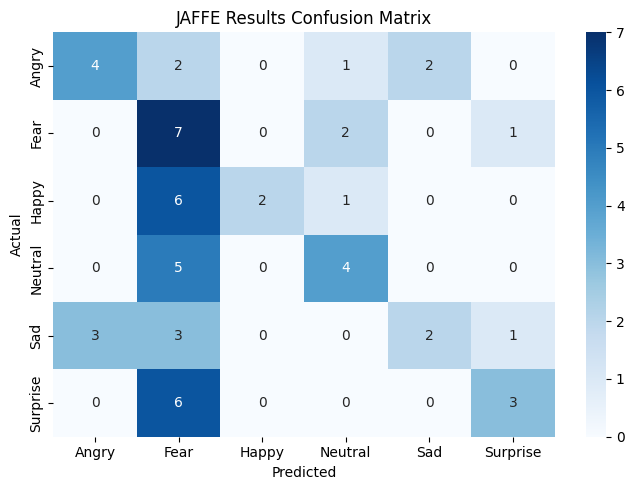


CK+ Results
Accuracy : 56.7 %
Precision: 0.5114
Recall   : 0.4927
F1-score : 0.4702

Classification Report
              precision    recall  f1-score   support

       anger       0.29      0.14      0.19        14
        fear       0.14      0.14      0.14         7
       happy       0.92      0.52      0.67        21
     neutral       0.60      0.52      0.56        23
     sadness       0.20      0.62      0.30         8
    surprise       0.92      1.00      0.96        24

    accuracy                           0.57        97
   macro avg       0.51      0.49      0.47        97
weighted avg       0.64      0.57      0.58        97



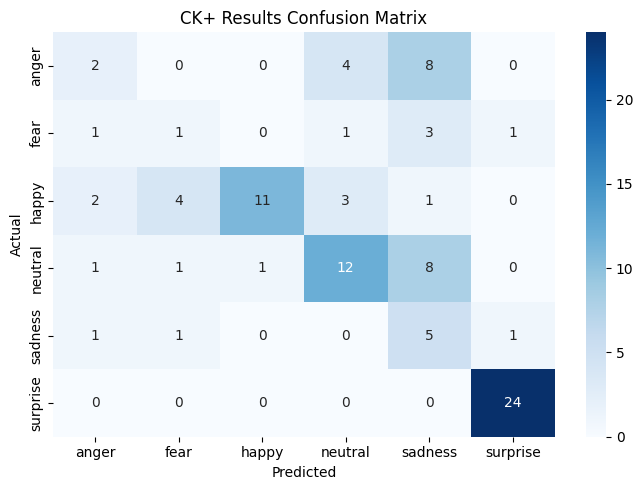

In [ ]:
# CELL 17: EVALUATE BOTH
jaffe_metrics = evaluate_model(jaffe_model, jaffe_test_ds, jaffe_classes, "JAFFE Results")
ck_metrics = evaluate_model(ck_model, ck_test_ds, ck_classes, "CK+ Results")

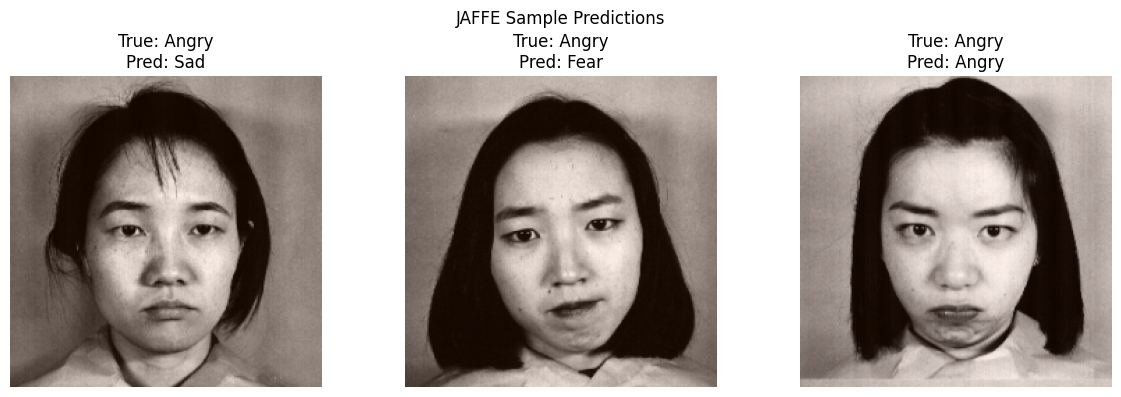

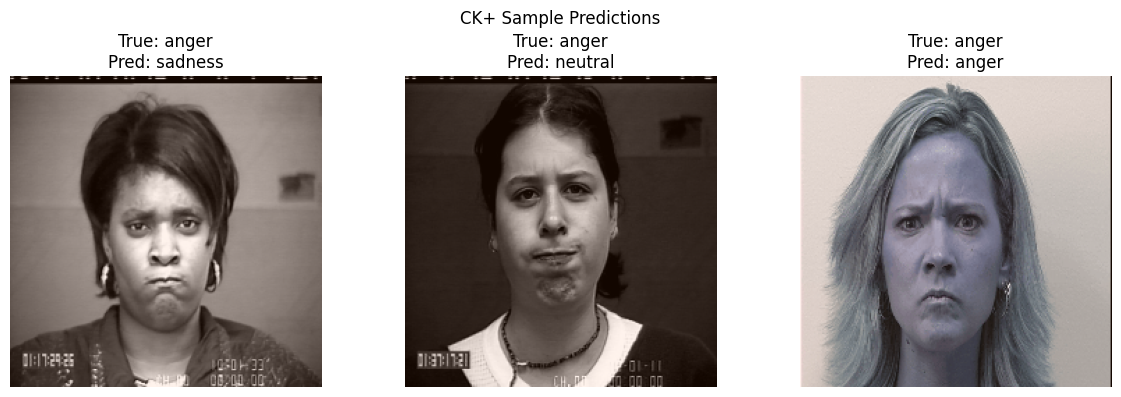

In [ ]:
# CELL 18: SHOW 3 PREDICTIONS
def show_three_predictions(model, dataset, class_names, title):
    images_batch, labels_batch = next(iter(dataset))
    preds = model.predict(images_batch, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 4))
    for i in range(3):
        img = images_batch[i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        plt.subplot(1, 3, i + 1)
        plt.imshow(img.astype("float32"))
        plt.title(f"True: {class_names[int(labels_batch[i])]}\nPred: {class_names[int(pred_labels[i])]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_three_predictions(jaffe_model, jaffe_test_ds, jaffe_classes, "JAFFE Sample Predictions")
show_three_predictions(ck_model, ck_test_ds, ck_classes, "CK+ Sample Predictions")

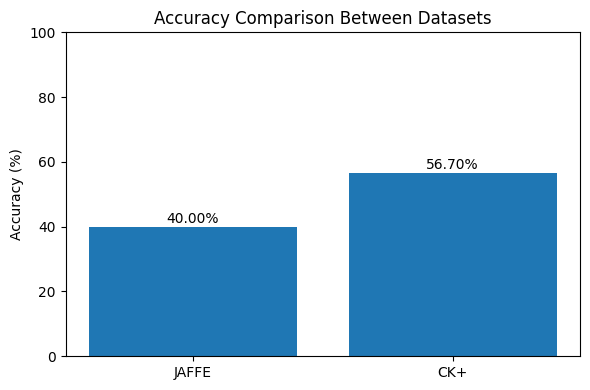

In [ ]:
# CELL 19: BAR CHART COMPARISON
datasets = ["JAFFE", "CK+"]
accuracies = [jaffe_metrics[0] * 100, ck_metrics[0] * 100]

plt.figure(figsize=(6, 4))
bars = plt.bar(datasets, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Between Datasets")
plt.ylim(0, 100)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# CELL 20: RESULT TABLE

import pandas as pd

results_df = pd.DataFrame({
    "Dataset": ["JAFFE", "CK+"],
    "Accuracy (%)": [round(jaffe_metrics[0] * 100, 2), round(ck_metrics[0] * 100, 2)],
    "Precision": [round(jaffe_metrics[1], 4), round(ck_metrics[1], 4)],
    "Recall": [round(jaffe_metrics[2], 4), round(ck_metrics[2], 4)],
    "F1-score": [round(jaffe_metrics[3], 4), round(ck_metrics[3], 4)]
})

print(results_df)

  Dataset  Accuracy (%)  Precision  Recall  F1-score
0   JAFFE          40.0     0.5688  0.3944    0.4049
1     CK+          56.7     0.5114  0.4927    0.4702


In [ ]:
# CELL 21: SAVE MODELS

jaffe_model.save("/content/final_jaffe_model.keras")
ck_model.save("/content/final_ck_model.keras")
print("Models saved successfully.")

Models saved successfully.


In [ ]:
# CELL 22: OPTIONAL DOWNLOAD
from google.colab import files
files.download("/content/final_jaffe_model.keras")
files.download("/content/final_ck_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>